In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

train = pd.read_csv("../data/processed/train.csv").dropna()
test = pd.read_csv("../data/processed/test.csv").dropna()

X_train, y_train = train["text_clean"], train["label"]
X_test, y_test = test["text_clean"], test["label"]
print(X_train.shape, X_test.shape)

(23812,) (5954,)


In [2]:
pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=3, max_df=0.95, max_features=50000)),
    ("nb", MultinomialNB())
])

debut = time.time()
pipe_nb.fit(X_train, y_train)
temps = time.time() - debut
print("Temps d'entraînement : {:.2f} s".format(temps))

Temps d'entraînement : 4.40 s


In [3]:
y_pred = pipe_nb.predict(X_test)

print("Accuracy  : {:.4f}".format(accuracy_score(y_test, y_pred)))
print("Précision : {:.4f}".format(precision_score(y_test, y_pred)))
print("Rappel    : {:.4f}".format(recall_score(y_test, y_pred)))
print("F1-score  : {:.4f}".format(f1_score(y_test, y_pred)))

print("\n", classification_report(y_test, y_pred, target_names=["Non-spam", "Spam"], digits=4))

Accuracy  : 0.9871
Précision : 0.9885
Rappel    : 0.9839
F1-score  : 0.9862

               precision    recall  f1-score   support

    Non-spam     0.9858    0.9899    0.9878      3159
        Spam     0.9885    0.9839    0.9862      2795

    accuracy                         0.9871      5954
   macro avg     0.9872    0.9869    0.9870      5954
weighted avg     0.9871    0.9871    0.9871      5954



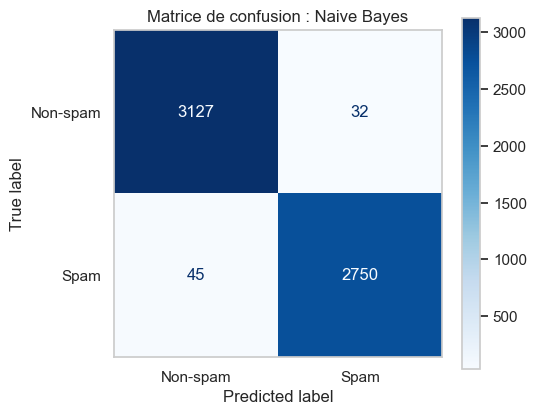

Vrais négatifs : 3127 | Faux positifs : 32
Faux négatifs  : 45 | Vrais positifs : 2750


In [4]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Non-spam", "Spam"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Matrice de confusion : Naive Bayes")
ax.grid(False)
plt.tight_layout()
plt.savefig("../images/05_matrice_confusion_nb.png", dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Vrais négatifs : {tn} | Faux positifs : {fp}")
print(f"Faux négatifs  : {fn} | Vrais positifs : {tp}")

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe_nb, X_train, y_train, cv=cv, scoring="f1")

print("F1 par pli :", scores.round(4))
print("F1 moyen : {:.4f} (± {:.4f})".format(scores.mean(), scores.std()))

F1 par pli : [0.9852 0.9838 0.9863 0.9845 0.9852]
F1 moyen : 0.9850 (± 0.0008)


In [6]:
vocab = np.array(pipe_nb.named_steps["tfidf"].get_feature_names_out())
nb = pipe_nb.named_steps["nb"]

diff = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]   # >0 : plutôt spam
ordre = diff.argsort()

print("Mots les plus associés au SPAM :")
print(list(vocab[ordre[::-1][:20]]))
print("\nMots les plus associés au NON-SPAM :")
print(list(vocab[ordre[:20]]))

Mots les plus associés au SPAM :
['viagra', 'cialis', 'pills', 'meds', 'xp', 'php', 'drugs', 'oo', 'prescription', 'rolex', 'pharmacy', 'utf', 'softwares', 'medications', 'sex', 'penis', 'computron', 'adobe', 'photoshop', 'cheap']

Mots les plus associés au NON-SPAM :
['enron', 'ect', 'vince', 'hourahead', 'hpl', 'kaminski', 'xls', 'louise', 'hou', 'schedules', 'mmbtu', 'scheduling', 'variances', 'ena', 'portland', 'westdesk', 'daren', 'meter', 'parsing', 'forwarded']


In [7]:
resultats = pd.DataFrame([{
    "modèle": "Naive Bayes + TF-IDF",
    "accuracy": accuracy_score(y_test, y_pred),
    "précision": precision_score(y_test, y_pred),
    "rappel": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "faux_positifs": fp,
    "faux_négatifs": fn,
    "f1_validation_croisée": scores.mean(),
    "temps_entraînement_s": round(temps, 2),
}])
resultats.to_csv("../data/processed/resultats.csv", index=False)
resultats.round(4)

,modèle,accuracy,précision,rappel,f1,faux_positifs,faux_négatifs,f1_validation_croisée,temps_entraînement_s
0,Naive Bayes + TF-IDF,0.9871,0.9885,0.9839,0.9862,32,45,0.985,4.4
